# Notebook 01 — Data Inspection
## Arabic ITSM Ticket Dataset: Exploratory Data Analysis

**Project**: Cloud-Based ITSM Ticket Classification Platform Using Fine-Tuned Transformer Models  
**Author**: Mohamed A. Elbaz  
**Supervisor**: Dr. Eman E. Sanad, FCAI, Cairo University  
**Date**: February 2026

---

### Objective

This notebook performs a thorough exploratory analysis of the **Arabic ITSM Dataset** — 10,000 synthetic Egyptian Arabic IT support tickets annotated with a 3-level ITSM taxonomy, priority scores, and sentiment labels.

Key questions addressed:
1. What is the class distribution at each taxonomy level (L1, L2, L3)?
2. Is the dataset balanced across classes and labels?
3. What are the text length characteristics (title and description)?
4. How are sentiment, channel, and priority distributed?
5. Are there any data quality issues (nulls, duplicates, inconsistencies)?

**Dataset**:
- HuggingFace: [`albaz2000/arabic-itsm-dataset`](https://huggingface.co/datasets/albaz2000/arabic-itsm-dataset)
- GitHub: [`bazokhan/arabic-itsm-dataset`](https://github.com/bazokhan/arabic-itsm-dataset)

Loaded directly from GitHub — no local clone required.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# ── Dataset — loaded directly from GitHub, no local clone needed ───────────────
DATA_URL     = 'https://raw.githubusercontent.com/bazokhan/arabic-itsm-dataset/master/dataset_clean.csv'
TAXONOMY_URL = 'https://raw.githubusercontent.com/bazokhan/arabic-itsm-dataset/master/taxonomy_itsm_v1.json'

RESULTS_DIR = Path('../results/figures')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Dataset: {DATA_URL}')

Dataset: https://raw.githubusercontent.com/bazokhan/arabic-itsm-dataset/master/dataset_clean.csv


## 1. Load Dataset

In [2]:
df = pd.read_csv(DATA_URL)
print(f'Shape: {df.shape}')
print(f'\nColumns ({len(df.columns)}):')
for col in df.columns:
    print(f'  {col:<25} {df[col].dtype}')

Shape: (10000, 18)

Columns (18):
  ticket_id                 object
  created_at                object
  updated_at                object
  channel                   object
  model                     object
  dialect                   object
  title_ar                  object
  description_ar            object
  category_level_1          object
  category_level_2          object
  category_level_3          object
  category_path             object
  tags                      object
  labels_json               object
  impact                    int64
  urgency                   int64
  priority                  int64
  sentiment                 object


In [3]:
# Display sample tickets (rendered with Arabic text)
pd.set_option('display.max_colwidth', 80)
df[['ticket_id', 'title_ar', 'description_ar', 'category_level_1', 'category_level_2',
    'category_level_3', 'priority', 'sentiment']].sample(5, random_state=42)

,ticket_id,title_ar,description_ar,category_level_1,category_level_2,category_level_3,priority,sentiment
6252,TCKT-013-253,كيبورد بايظة - 253,في زراير في الكيبورد مش شغالة خالص. بقالها 7 ساعة تقريبا. جربت ريستارت وكمان...,Access,Account,Password Reset,4,negative
4684,TCKT-010-185,مشكلة في Keyboard/Mouse,يا جماعة الـ Keyboard/Mouse مش شغال خالص وبقالي كتير بحاول. بقالها 4 ساعة تق...,Hardware,Peripherals,Keyboard/Mouse,2,neutral
1731,TCKT-004-232,مفيش إذن دخول,كل ما أفتح الملف بيقولي Access Denied، مع إني المفروض ليا صلاحية. بقالها 24 ...,Access,Permissions,Permission Denied,4,negative
4742,TCKT-010-243,طلب بخصوص Device Encryption,لو سمحتوا محتاج مساعدة في الـ Device Encryption، الموضوع مستعجل. بقالها 24 س...,Security,Policy/Compliance,Device Encryption,4,neutral
4521,TCKT-010-022,بطل يشتغل Authenticator Issue,الـ Authenticator Issue فجأة كده مابقاش يفتح، جربت أرستر وبرضه مفيش فايدة. ب...,Access,MFA/SSO,Authenticator Issue,2,mixed


## 2. Missing Values & Duplicates

In [4]:
print('=== Missing Values ===')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.any() else 'No missing values.')

print('\n=== Duplicate ticket_id ===')
dup = df['ticket_id'].duplicated().sum()
print(f'{dup} duplicate ticket IDs')

print('\n=== Duplicate (title, description) pairs ===')
dup_text = df.duplicated(subset=['title_ar', 'description_ar']).sum()
print(f'{dup_text} exact text duplicates')

=== Missing Values ===
No missing values.

=== Duplicate ticket_id ===
0 duplicate ticket IDs

=== Duplicate (title, description) pairs ===
451 exact text duplicates


## 3. Class Distribution

The taxonomy has 3 levels: L1 (6 classes) → L2 (16 classes) → L3 (48 classes).
Understanding the distribution is critical for choosing appropriate evaluation metrics
and identifying potential class imbalance challenges.

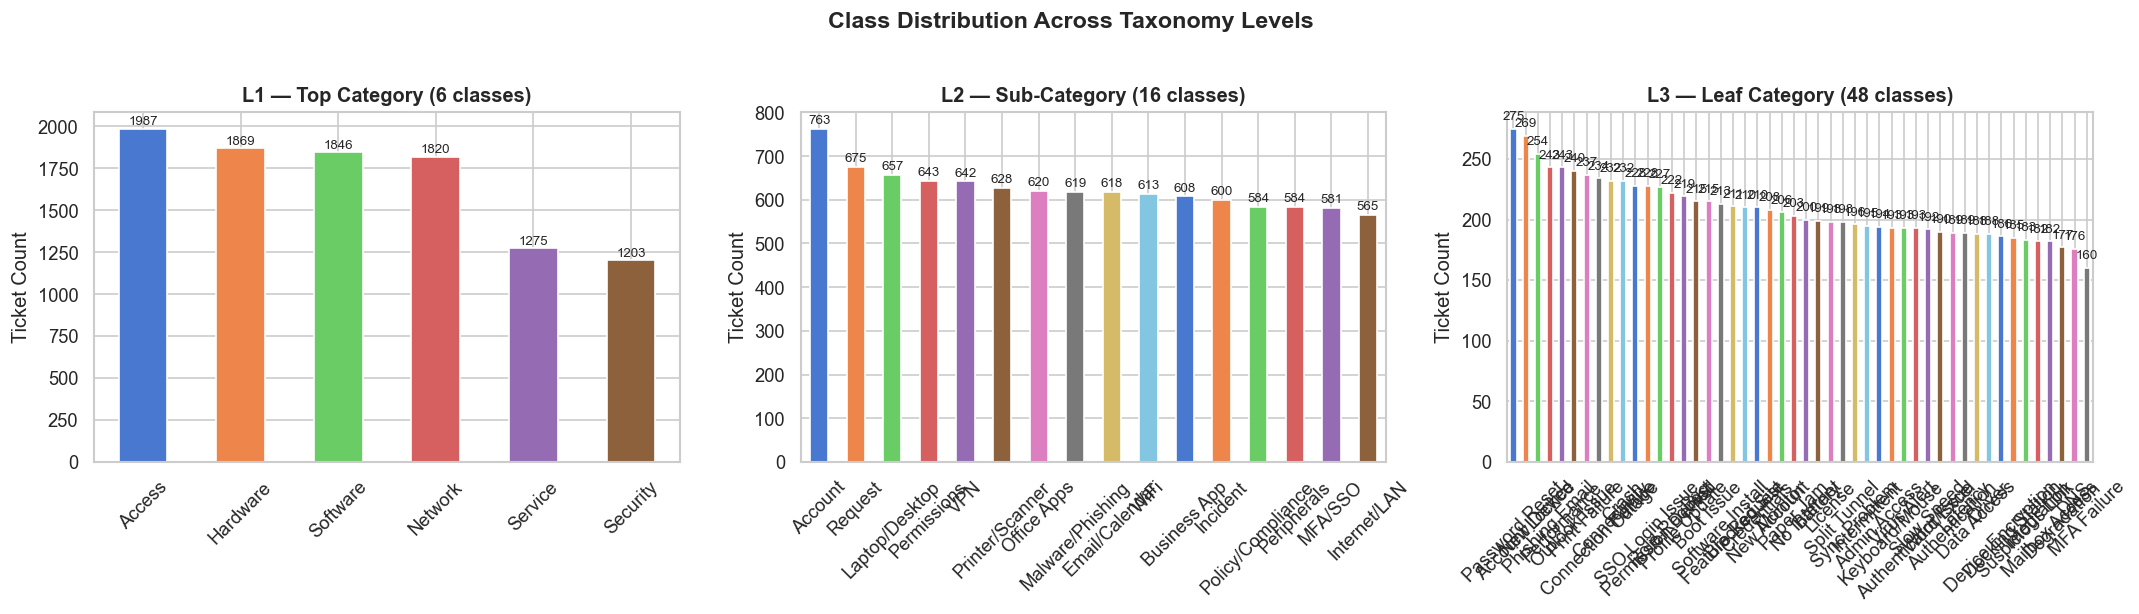

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, title) in zip(axes, [
    ('category_level_1', 'L1 — Top Category (6 classes)'),
    ('category_level_2', 'L2 — Sub-Category (16 classes)'),
    ('category_level_3', 'L3 — Leaf Category (48 classes)'),
]):
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(counts)))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Ticket Count')
    ax.tick_params(axis='x', rotation=45)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                int(bar.get_height()), ha='center', va='bottom', fontsize=8)

plt.suptitle('Class Distribution Across Taxonomy Levels', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_class_distribution.png', bbox_inches='tight')
plt.show()

In [6]:
# Class balance summary
print('=== L1 Class Balance ===')
l1_counts = df['category_level_1'].value_counts()
l1_df = pd.DataFrame({'count': l1_counts, 'share_%': (l1_counts / len(df) * 100).round(1)})
l1_df['imbalance_ratio'] = (l1_df['count'].max() / l1_df['count']).round(2)
print(l1_df)

print(f'\nOverall imbalance ratio (max/min count): {l1_counts.max() / l1_counts.min():.2f}x')

print('\n=== L2 Summary ===')
l2_counts = df['category_level_2'].value_counts()
print(f'Min: {l2_counts.min()}, Max: {l2_counts.max()}, Mean: {l2_counts.mean():.0f}')

print('\n=== L3 Summary ===')
l3_counts = df['category_level_3'].value_counts()
print(f'Min: {l3_counts.min()}, Max: {l3_counts.max()}, Mean: {l3_counts.mean():.0f}')

=== L1 Class Balance ===
                  count  share_%  imbalance_ratio
category_level_1                                 
Access             1987     19.9             1.00
Hardware           1869     18.7             1.06
Software           1846     18.5             1.08
Network            1820     18.2             1.09
Service            1275     12.8             1.56
Security           1203     12.0             1.65

Overall imbalance ratio (max/min count): 1.65x

=== L2 Summary ===
Min: 565, Max: 763, Mean: 625

=== L3 Summary ===
Min: 160, Max: 275, Mean: 208


## 4. Text Length Analysis

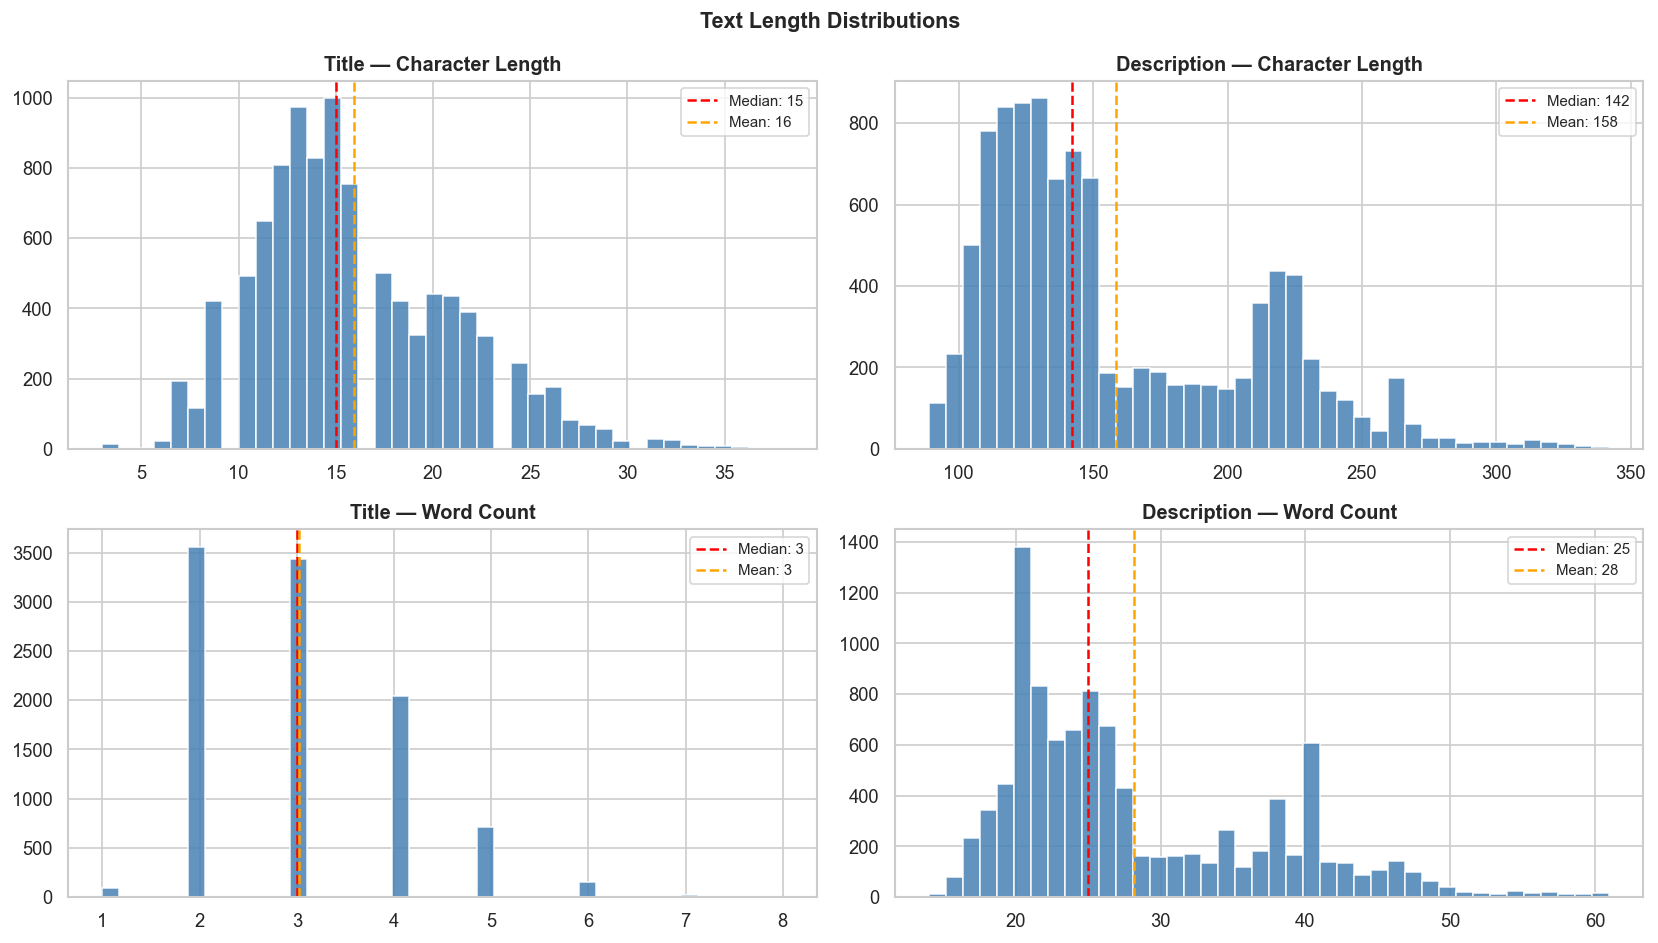

       title_len  desc_len  title_words  desc_words
count    10000.0   10000.0      10000.0     10000.0
mean        15.9     158.4          3.0        28.2
std          5.2      49.1          1.0         9.0
min          3.0      89.0          1.0        14.0
25%         12.0     121.0          2.0        22.0
50%         15.0     142.0          3.0        25.0
75%         19.0     199.0          4.0        35.0
max         38.0     342.0          8.0        61.0


In [7]:
df['title_len'] = df['title_ar'].str.len()
df['desc_len'] = df['description_ar'].str.len()
df['title_words'] = df['title_ar'].str.split().str.len()
df['desc_words'] = df['description_ar'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col, label in [
    (axes[0,0], 'title_len', 'Title — Character Length'),
    (axes[0,1], 'desc_len', 'Description — Character Length'),
    (axes[1,0], 'title_words', 'Title — Word Count'),
    (axes[1,1], 'desc_words', 'Description — Word Count'),
]:
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].median(), color='red', linestyle='--', label=f'Median: {df[col].median():.0f}')
    ax.axvline(df[col].mean(), color='orange', linestyle='--', label=f'Mean: {df[col].mean():.0f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Text Length Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_text_lengths.png', bbox_inches='tight')
plt.show()

print(df[['title_len', 'desc_len', 'title_words', 'desc_words']].describe().round(1))

## 5. Priority, Sentiment, and Channel Distributions

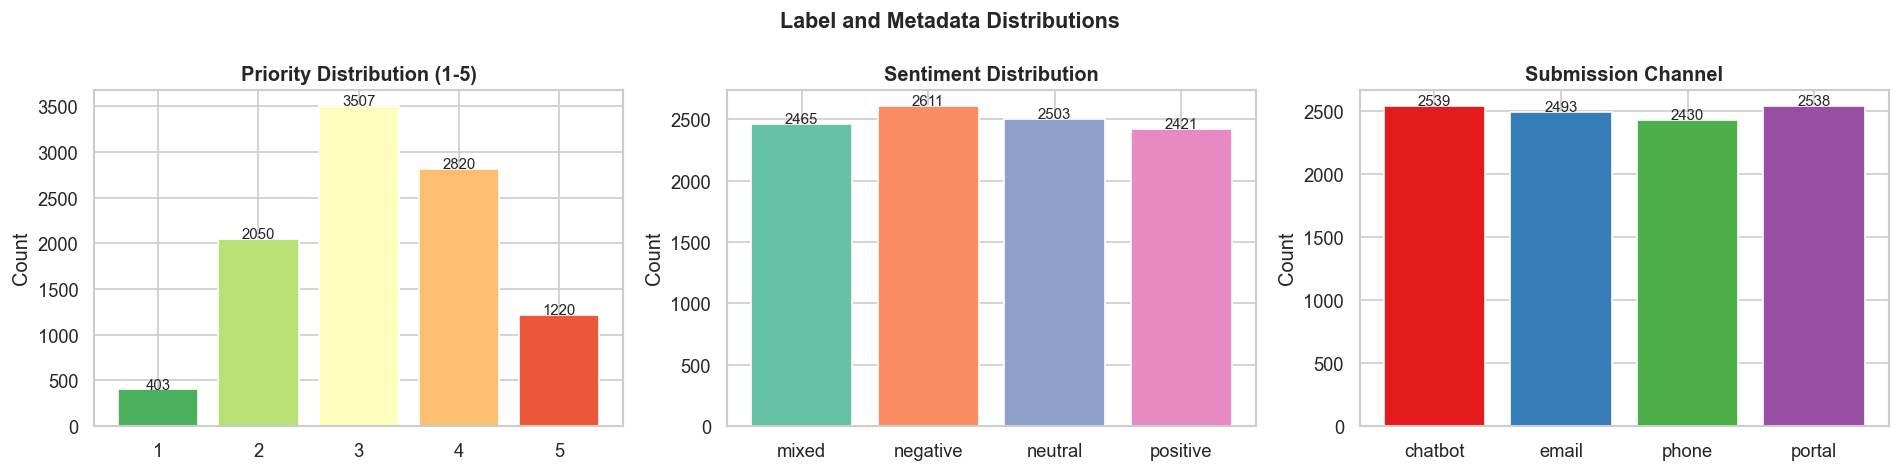

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col, title, palette) in zip(axes, [
    ('priority', 'Priority Distribution (1-5)', 'RdYlGn_r'),
    ('sentiment', 'Sentiment Distribution', 'Set2'),
    ('channel', 'Submission Channel', 'Set1'),
]):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=sns.color_palette(palette, len(counts)))
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                int(bar.get_height()), ha='center', fontsize=9)

plt.suptitle('Label and Metadata Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_label_distributions.png', bbox_inches='tight')
plt.show()

## 6. Cross-tabulations

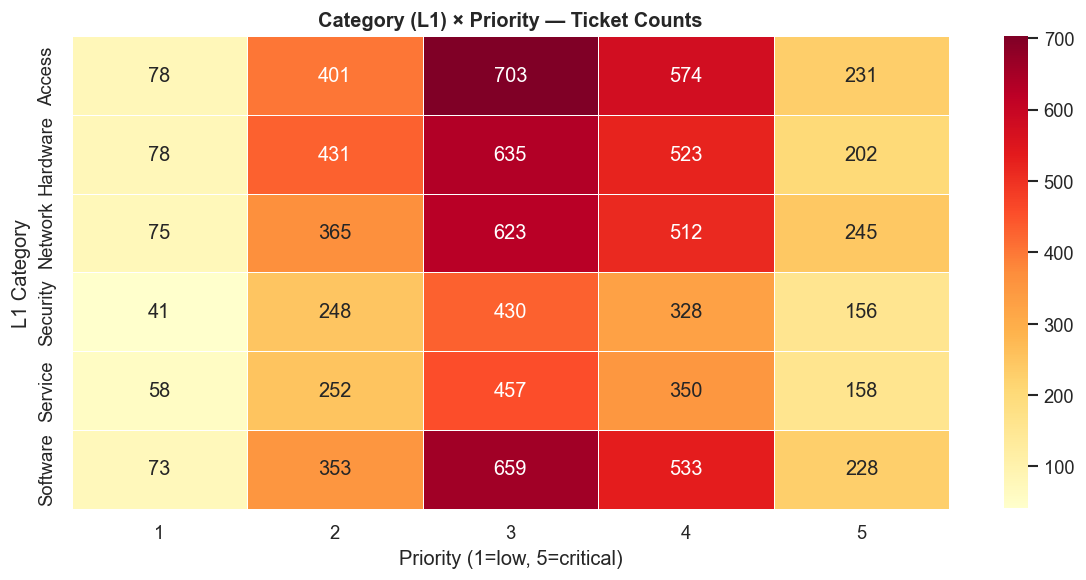

In [9]:
# L1 category × Priority heatmap
pivot = df.pivot_table(index='category_level_1', columns='priority', aggfunc='size', fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Category (L1) × Priority — Ticket Counts', fontweight='bold')
plt.xlabel('Priority (1=low, 5=critical)')
plt.ylabel('L1 Category')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_category_priority_heatmap.png', bbox_inches='tight')
plt.show()

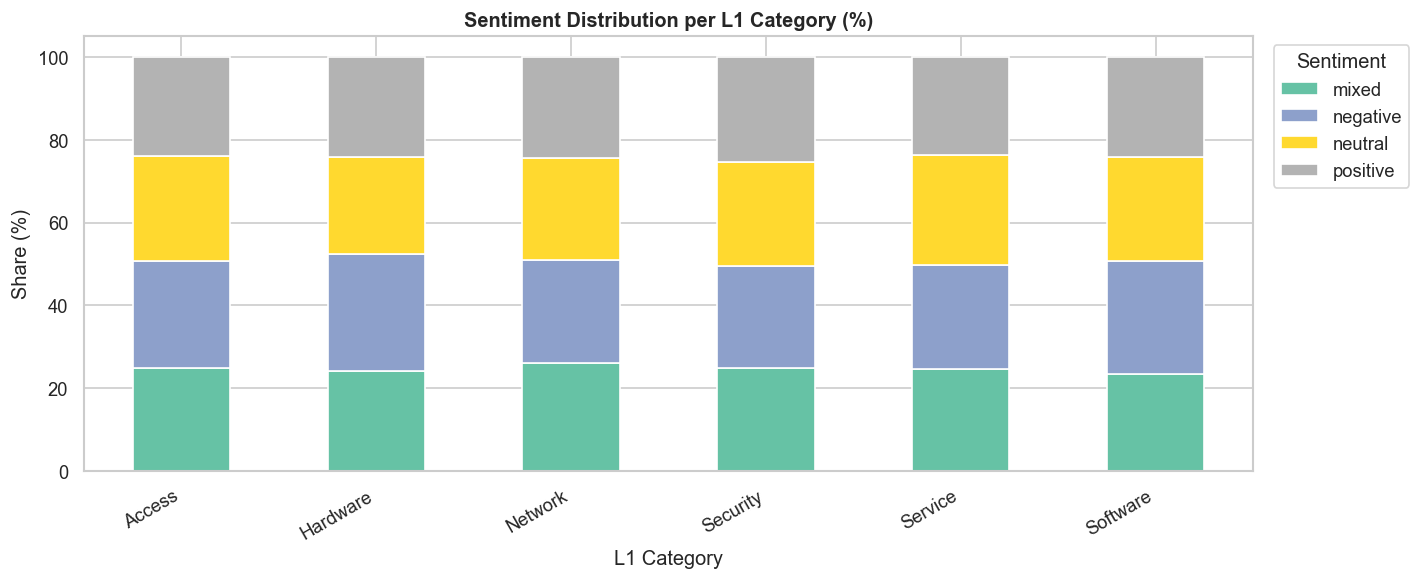

In [10]:
# L1 category × Sentiment
pivot_s = df.pivot_table(index='category_level_1', columns='sentiment', aggfunc='size', fill_value=0)

pivot_s_pct = pivot_s.div(pivot_s.sum(axis=1), axis=0) * 100
pivot_s_pct.plot(kind='bar', stacked=True, figsize=(12, 5),
                 colormap='Set2', edgecolor='white')
plt.title('Sentiment Distribution per L1 Category (%)', fontweight='bold')
plt.xlabel('L1 Category')
plt.ylabel('Share (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sentiment', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_category_sentiment.png', bbox_inches='tight')
plt.show()

## 7. Summary

| Metric | Value |
|--------|-------|
| Total tickets | 10,000 |
| Missing values | 0 |
| Duplicate texts | 451 exact (title, description) duplicates in raw source; removed in Notebook 02 preprocessing |
| L1 imbalance ratio | See above |
| Avg description length | ~200 chars / ~35 words |

**Key observations for model design:**
- Dataset is reasonably balanced at L1 (6 classes). Macro-F1 is the appropriate primary metric.
- L3 has 48 classes with ~208 samples/class on average — hierarchical classification remains important.
- Description text is short (helpdesk-style), which is well-suited for MarBERT's 128-token default.
- Code-mixing (Arabic + English technical terms) is present throughout — validates the MarBERT choice.

**Next**: Notebook 02 — Data Preparation (normalization, splits, tokenization)